# Folded-Clos Topology Visualization Example

This notebook demonstrates how to generate and visualize a single Folded-Clos topology with a 3-level hierarchy (Server -> Nodes -> NPUs).

In [50]:
import sys
sys.path.insert(0, '/app/astra-sim/upc/create_topology/old')

import importlib
import matplotlib.pyplot as plt

# Reload modules to pick up any changes
import create_topology
importlib.reload(create_topology)
import utils
importlib.reload(utils)

from create_topology import FoldedClos
from utils import visualize_topology, visualize_single_server
from create_topology_main import generate_topology_files

## 1. Define Topology Configuration

Here, we define the configuration for a K=4 Folded-Clos (Fat-Tree) with a 3-level hierarchy:
- **16 Servers**: The base fat-tree has 16 servers.
- **2 Nodes per Server**: Each server is divided into 2 logical nodes.
- **4 NPUs per Node**: Each node contains 4 NPUs.
- **Total NPUs**: 16 * 2 * 4 = 128 NPUs.

In [51]:
# Define bandwidth configuration for the topology
bw_config = {
    'host_edge': 25,         # Host (ToR) to edge switch
    'edge_agg': 25,          # Edge to aggregation switch
    'agg_core': 25,          # Aggregation to core switch
    'intra_node': 100         # Within a node (NPU to NPU-switch)
}

# Create an instance of the FoldedClos topology
config = {
    'K': 4,
    'bandwidth_config': bw_config,
    'bw_unit': 'GB/s',
    'nodes_per_server':1,
    'npus_per_node': 8,
    'intra_node_topology': 'switch',
    'num_nvswitches': 1  # Using 2 NVSwitches per node for redundancy/performance
}
fc_3level = FoldedClos(
    K=4,                      # K=4 fat-tree results in 16 servers
    bandwidth_config=bw_config,
    nodes_per_server=1,       # 2 nodes per server
    npus_per_node=8,          # 4 NPUs per node
    intra_node_topology='switch',
    # num_nvswitches=1
)

print("Folded-Clos Configuration:")
print(f"  - K: {fc_3level.K}")
print(f"  - Total servers: {fc_3level.total_num_servers}")
print(f"  - Nodes per server: {fc_3level.nodes_per_server}")
print(f"  - Total nodes (sub-groups): {fc_3level.total_num_nodes}")
print(f"  - NPUs per node: {fc_3level.npus_per_node}")
print(f"  - Total NPUs: {fc_3level.total_num_hosts}")

generate_topology_files('FoldedClos', 'ECMP', config, '.', 'AIAI')

Folded-Clos Configuration:
  - K: 4
  - Total servers: 16
  - Nodes per server: 1
  - Total nodes (sub-groups): 16
  - NPUs per node: 8
  - Total NPUs: 128
--- Generating FoldedClos with ECMP routing ---
Formula: Servers = K^3 / 4 = 16
         Nodes = Servers(16) * nodes_per_server(1) = 16
         NPUs = Nodes(16) * npus_per_node(8) = 128
         Intra-node topology: switch
*** Generating ECMP flow dict for folded clos K = 4
Writing files to: .
Successfully wrote custom text topology to ./AIAI.txt
Successfully wrote JSON topology to ./AIAI.json
Successfully wrote NS3 topology to ./AIAI


## 2. Visualize the Full Topology

This visualization shows the entire 128-NPU network. It can be complex, but it illustrates the overall structure with Core, Aggregation, and Edge switches.

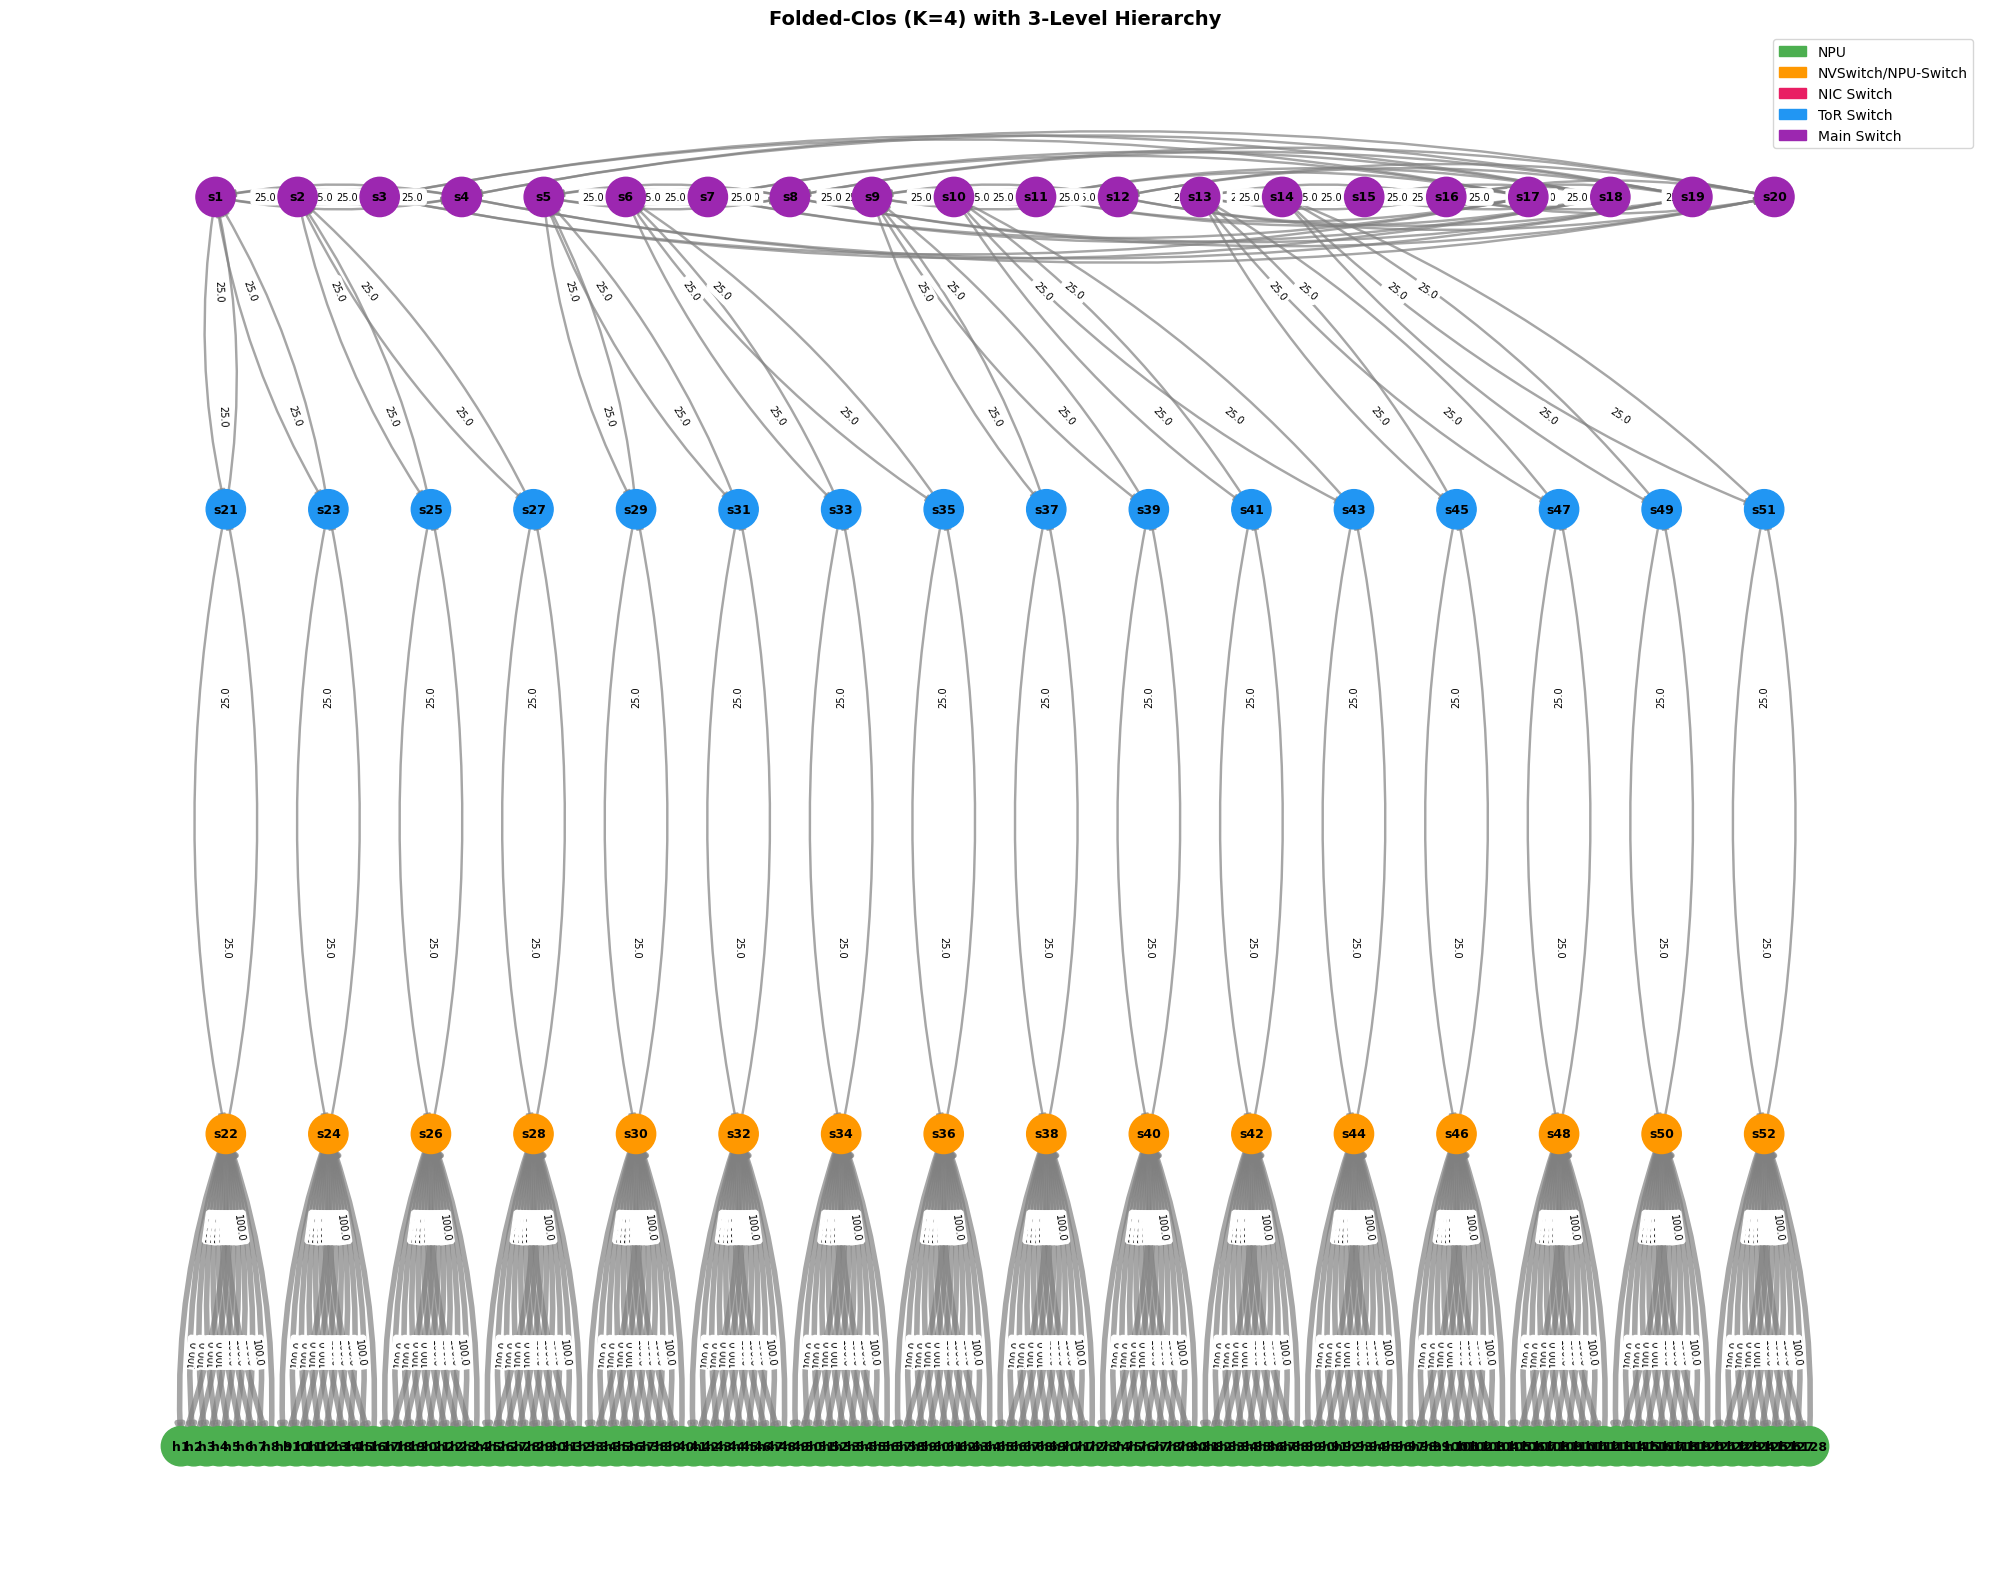

In [52]:
# Visualize the entire topology
# Note: show_bw=False is used to keep the visualization clean for large graphs
fig, ax, G = visualize_topology(
    fc_3level, 
    "Folded-Clos (K=4) with 3-Level Hierarchy", 
    figsize=(20, 16), 
    show_bw=True
)
plt.show()

## 3. Visualize a Single Server

To better understand the 3-level hierarchy, we can zoom in on a single server. This view clearly shows the server's internal structure: its nodes, the NPUs within each node, and how they connect to the network's ToR switch.

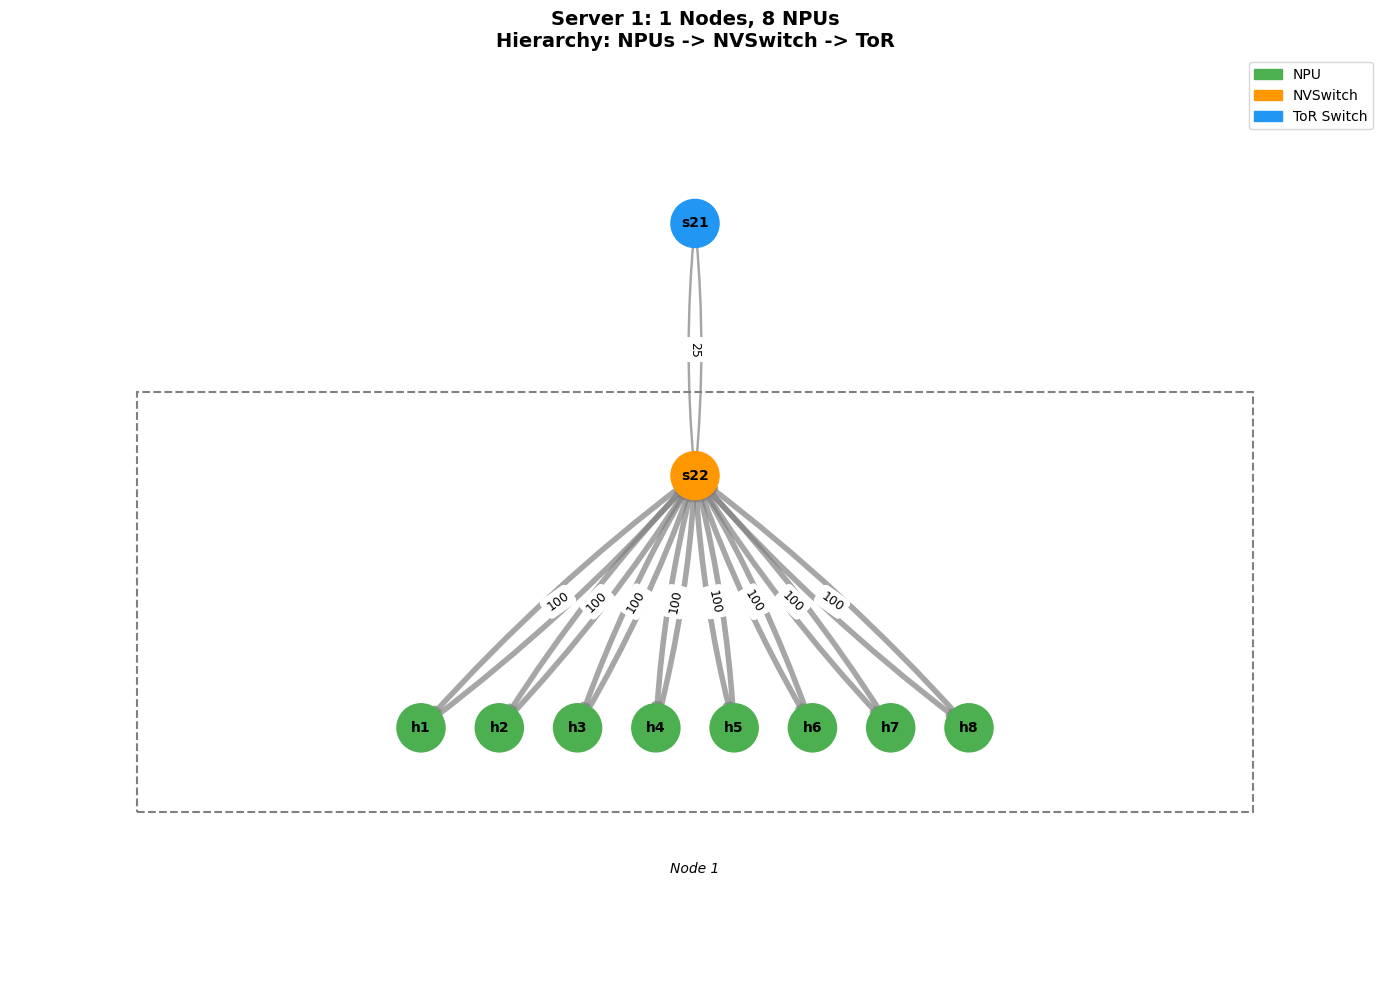


Details for Server 0:
  - Nodes in this server: []


In [53]:
# Visualize a single server to see the node->NPU hierarchy
visualize_single_server(fc_3level, server_idx=1)
plt.show()

print(f"\nDetails for Server 0:")
server_nodes = fc_3level.server_nodes.get(0, [])
print(f"  - Nodes in this server: {server_nodes}")
for node_id in server_nodes:
    node_npus = fc_3level.node_npus.get(node_id, [])
    print(f"    - Node {node_id} contains NPUs: {node_npus}")